In [2]:
!pip install kaggle

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1773596713.400637   21697 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773596714.358511   21697 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773596718.846627   21697 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [13]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle datasets list

ref                                                          title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                             55017  2026-02-22 18:18:38.170000           8528        166                1  
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                  24420255  2026-03-07 04:58:02.387000           2305         50                1  
jayjoshi37/sleep-screen-time-and-stress-analysis             Sleep, Screen Time and Stress Analysis                 310158  2026-03-11 14:21:59.017000           1078         26                1  
shree0910/ai-and-dat

In [17]:
#!/bin/bash
!kaggle datasets download tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100%|█████████████████████████████████████████| 218M/218M [00:01<00:00, 165MB/s]



In [4]:
import zipfile

zip_ref = zipfile.ZipFile("cat-and-dog.zip")
zip_ref.extractall("dataset")
zip_ref.close()

In [5]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/training_set/training_set",
    image_size=(150,150),
    batch_size=32
)

Found 8005 files belonging to 2 classes.


I0000 00:00:1773596775.158290   21697 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [6]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/test_set/test_set",
    image_size=(150,150),
    batch_size=32
)

Found 2023 files belonging to 2 classes.


In [7]:
train_data = train_data.map(lambda x,y: (x/255, y))
test_data = test_data.map(lambda x,y: (x/255, y))

In [8]:
for images, labels in train_data.take(1):
    print(images.shape)
    print(labels)

(32, 150, 150, 3)
tf.Tensor([0 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0], shape=(32,), dtype=int32)


In [9]:
from tensorflow.keras import layers
from tensorflow.keras import models

In [10]:
model = models.Sequential([
    
    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10


I0000 00:00:1773597060.585630   27788 service.cc:153] XLA service 0x7b90cc0058c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773597060.585662   27788 service.cc:161]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 12.8.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773597060.717189   27788 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773597061.270707   27788 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1773597061.319397   27788 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2068__.35


  4/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4922 - loss: 0.9869  

I0000 00:00:1773597066.751792   27788 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5404 - loss: 0.7207

I0000 00:00:1773597077.215477   27790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2068__.35
E0000 00:00:1773597077.590813   27790 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


251/251 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5810 - loss: 0.6827 - val_accuracy: 0.5457 - val_loss: 0.7545
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.6727 - loss: 0.6053 - val_accuracy: 0.7019 - val_loss: 0.5828
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.7412 - loss: 0.5181 - val_accuracy: 0.7222 - val_loss: 0.5463
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.7998 - loss: 0.4236 - val_accuracy: 0.7217 - val_loss: 0.6335
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8478 - loss: 0.3370 - val_accuracy: 0.7464 - val_loss: 0.5737
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8978 - loss: 0.2353 - val_accuracy: 0.7435 - val_loss: 0.7401
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9399 - loss: 0.1524 - val_accuracy: 0.7261 - val_loss: 0.8746
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.9649 - loss: 0.0934 - val_accurac

In [14]:
model.save("cats_dogs_cnn_model.h5")

In [15]:
model.evaluate(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7380 - loss: 1.2986


[1.2986159324645996, 0.7380128502845764]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


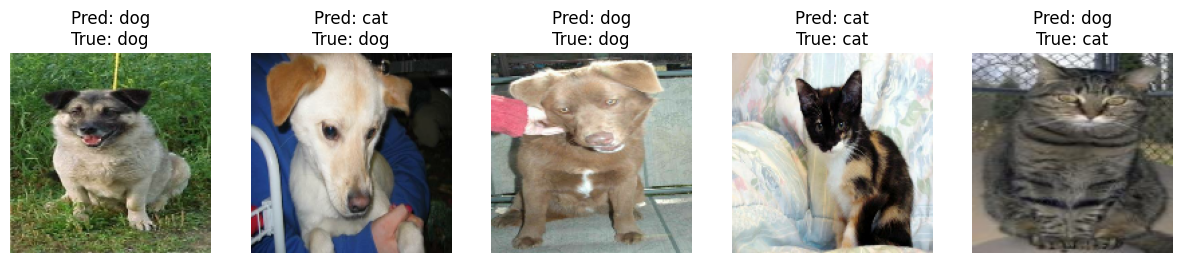

In [17]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['cat','dog']

for images, labels in test_data.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(15,5))

    for i in range(5):

        plt.subplot(1,5,i+1)

        img = (images[i].numpy()*255).astype("uint8")

        plt.imshow(img)

        pred_label = class_names[int(predictions[i][0] > 0.5)]
        true_label = class_names[int(labels[i])]

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")

plt.show()

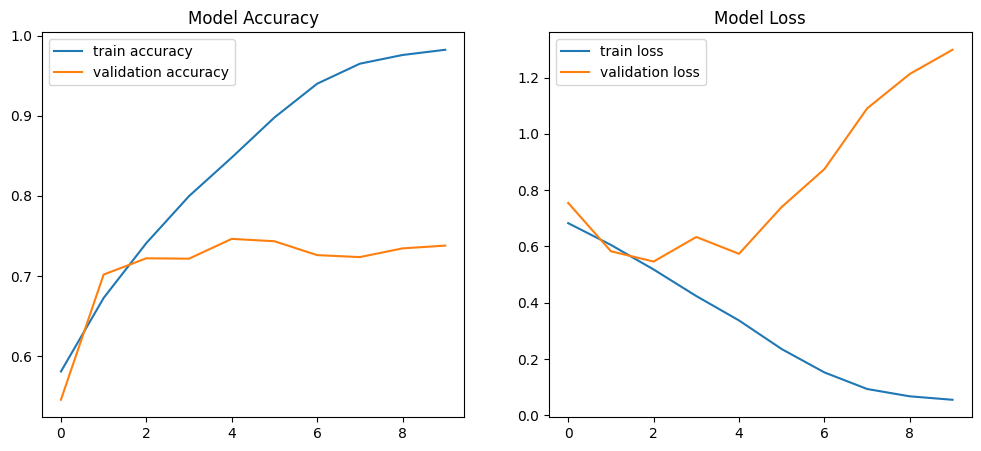

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title("Model Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title("Model Loss")
plt.legend()

plt.show()

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/teamspace/lightning_storage/cat_VS_dog/dataset/test_set/test_set/dogs/dog.4017.jpg", target_size=(150,150))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Dog


In [27]:
mkdir templates

In [28]:
mkdir static

In [30]:
touch .streamlit/config.toml

NameError: name 'touch' is not defined